# trying to find the rossby number in Mesa profiles
  
done  
- open a the trimmed history  
- identify which models numbers correspond to models with a radius of less than 2 R_sun and are under 9 Gyr  
- calculate and plot rossby number for these models
  
to do  
- find the radius at/ near where Ro = 1  
- Plot radius against time for Ro = 1  

### To change data all you should have to change are file locations. in code cell 5.

### $ R_o = {{u \cdot \nabla u} \over { 2 \Omega \times u}}$
simplifying to $ R_o ={u \over {2 \Omega L_m }}$
and $ u \propto \bigl( {{F(r)} \over {\rho(r)}} \bigr) ^{1/3} $ where L_u is relavent length scale and 
$ F = {{L_u} \over {4 \pi r^2}} $  
## **thus $ R_o \approx { \biggl(\frac{L_u}{4 \pi r^2 \rho}\biggr)^{1/3} \frac{1}{2 \Omega L_m} } $** 
$ R_o $: Rossby number  
$ L_u $: Luminosity  
$ r $: Radius  
$ \rho $: density  
$ \Omega $: angular velocity  
$ L_m $: Mixing length

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# Python module to handle MESA-Web output files
#
# (c) 2021-2023 Rich Townsend (rhtownsend@me.com)
#
# This module is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, version 3.
#
# This module is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU
# General Public License for more details.

__version__ = '2024.11.20'

# Imports

import os.path as op
import numpy as np
import re

# Read a MESA-Web history file

def read_history(filename, as_table=False):

    """Read data from a MESA-Web history file
    
    Parameters
    ----------
    
    filename -- string giving name of history file
    as_table -- boolean flag indicating the format of the data returned: 
                    True: return as astropy.table.Table object
                    False: return as Python dict (default)
    
    Returns
    -------

    hist_data -- dict or Table containing header and history data 
                 (see below for details)

    Header Data 
    -----------

    The following keys/value pairs in the returned dict (or the Table.meta dict)
    contain header data -- i.e., scalars describing time-independent properties
    of the star. Where applicable, units are given in square brackets [].

      version_number   -- version number of MESA
      compiler         -- name of compiler used to build MESA
      build            -- version of compiler used to build MESA
      MESA_SDK_version -- version of Software Development Kit used to build MESA
      date             -- date on which MESA-Web calculation began
      burn_min1        -- 1st limit for reported burning [erg/g/s]
      burn_min2        -- 2nd limit for reported burning [erg/g/s]

    History Data
    ------------

    The following keys/value pairs in the returned dict (or the Table) contain 
    history data -- i.e., arrays describing global properties of the star over
    a sequence of time-steps. Where applicable, units are given in
    square brackets [].

      model_number                  -- model number
      star_age                      -- stellar age [years]
      star_mass                     -- stellar mass [Msun]
      log_L                         -- log10(stellar luminosity [Lsun])
      log_R                         -- log10(stellar radius [Rsun])
      log_Teff                      -- log10(effective temperature [K])
      log_center_T                  -- log10(center temperature [K])
      log_center_Rho                -- log10(center density [g/cm^3])
      log_center_P                  -- log10(center pressure [dyn/cm^2])
      center_h1                     -- center 1H mass fraction
      center_he3                    -- center 3He mass fraction
      center_he4                    -- center 4He mass fraction
      center_c12                    -- center 12C mass fraction
      center_n14                    -- center 14N mass fraction
      center_o16                    -- center 16O mass fraction
      center_ne20                   -- center 20Ne mass fraction
      center_mg24                   -- center 24Mg mass fraction
      center_si28                   -- center 28Si mass fraction
      center_s32                    -- center 32S mass fraction
      center_ar36                   -- center 36Ar mass fraction
      center_ca40                   -- center 40Ca mass fraction
      center_ti44                   -- center 44Ti mass fraction
      center_cr48                   -- center 48Cr mass fraction
      center_fe52                   -- center 52Fe mass fraction
      center_fe54                   -- center 54Fe mass fraction
      center_fe56                   -- center 56Fe mass fraction
      center_ni56                   -- center 56Ni mass fraction
      center_degeneracy             -- center electron degeneracy parameter [kB*T]
      center_ye                     -- center average charge per baryon [e]
      center_entropy                -- center entropy [kB]
      compactness_parameter         -- (m/Msun)/(R(m)/1000km) for m = 2.5 Msun
      dynamic_timescale             -- dynamical timescale [s]
      kh_timescale                  -- Kelvin-Helmholtz timescale [s]
      nuc_timescale                 -- nuclear timescale [s]
      pp                            -- log10(total pp luminosity [Lsun])
      cno                           -- log10(total CNO luminosity [Lsun])
      tri_alfa                      -- log10(total triple-alpha luminosity [Lsun])
      log_LH                        -- log10(total H-burning luminosity, excluding neutrinos [Lsun])
      log_LHe                       -- log10(total He-burning luminosity, excluding neutrinos [Lsun])
      log_LZ                        -- log10(total metal-burning luminosity, excluding neutrinos [Lsun])
      log_Lneu                      -- log10(total neutrino luminosity [Lsun])
      he_core_mass                  -- mass of helium core [Msun]
      c_core_mass                   -- mass of carbon core [Msun]
      o_core_mass                   -- mass of oxygen core [Msun]
      si_core_mass                  -- mass of silicon core [Msun]
      fe_core_mass                  -- mass of iron core [Msun]
      he_core_radius                -- radius of helium core [Rsun]
      c_core_radius                 -- radius of carbon core [Rsun]
      o_core_radius                 -- radius of oxygen core [Rsun]
      si_core_radius                -- radius of silicon core [Rsun]
      fe_core_radius                -- radius of iron core [Rsun]
      max_abs_v_velocity            -- maximum absolute velocity 
      surf_avg_omega_div_omega_crit -- surface average rotation angular frequency [Omega_crit]
      log_total_angular_momentum    -- log10(total angular momentum [cm^2 g/s]
      surf_avg_omega                -- surface average rotation angular frequency [rad/s]
      surf_avg_v_rot                -- surface average rotation velocity [km/s]
      star_mdot                     -- mass-loss rate [Msun/year]

    """

    return __read_data(filename, as_table)


# Read a MESA-Web profile file

def read_profile(filename, as_table=False):

    """Read data from a MESA-Web profile file
    
    Parameters
    ----------
    
    filename -- string giving name of profile file
    as_table -- boolean flag indicating the format of the data returned: 
                    True: return as astropy.table.Table object
                    False: return as Python dict (default)
    
    Returns
    -------

    prof_data -- dict or Table containing header and profile data (see below for
                 details)

    Header Data
    -----------

    The following keys/value pairs in the returned dict (or Table.meta dict) 
    contain header data -- i.e., scalars describing position-independent 
    properties of the star. Where applicable, units are given in square 
    brackets [].

      star_mdot              -- mass-loss rate [Msun/year]
      model_number           -- model number
      num_zones              -- number of zones
      initial_mass           -- initial mass [Msun]
      initial_z              -- initial metal mass fraction
      star_age               -- stellar age [years]
      time_step              -- current time-step [s]
      Teff                   -- effective temperature [K]
      photosphere_L          -- photospheric luminosity [Lsun]
      photosphere_r          -- photospheric radius [Rsun]
      center_eta             -- center electron chemical potential [kB*T]
      center_h1              -- center 1H mass fraction
      center_he3             -- center 3He mass fraction
      center_he4             -- center 4He mass fraction
      center_c12             -- center 12C mass fraction
      center_n14             -- center 14N mass fraction
      center_o16             -- center 16O mass fraction
      center_ne20            -- center 20Ne mass fraction
      star_age               -- stellar age [years]
      star_mass              -- stellar mass [Msun]
      star_mdot              -- mass-loss rate [Msun/year]
      star_mass_h1           -- total mass in 1H [Msun]
      star_mass_he3          -- total mass in 3He [Msun]
      star_mass_he4          -- total mass in 4He [Msun]
      star_mass_c12          -- total mass in 12C [Msun]
      star_mass_n14          -- total mass in 14N [Msun]
      star_mass_o16          -- total mass in 16O [Msun]
      star_mass_ne20         -- total mass in 20Ne [Msun]
      he_core_mass           -- mass of helium core [Msun]
      c_core_mass            -- mass of carbon core [Msun]
      o_core_mass            -- mass of oxygen core [Msun]
      si_core_mass           -- mass of silicon core [Msun]
      fe_core_mass           -- mass of iron core [Msun]
      neutron_rich_core_mass -- mass of neutron-rich core [Msun]
      tau10_mass             -- mass coordinate of optical depth 10 [Msun]
      tau10_radius           -- radius coordinate of optical depth 10 [Rsun]
      tau100_mass            -- mass coordinate of optical depth 100 [Msun]
      tau100_radius          -- radius coordinate of optical depth 100 [Rsun]
      dynamic_timescale      -- dynamical timescale [s]
      kh_timescale           -- Kelvin-Helmholtz timescale [s]
      nuc_timescale          -- nuclear timescale [s]
      log_LH                 -- log10(total H-burning luminosity, excluding neutrinos [Lsun])
      log_LHe                -- log10(total He-burning luminosity, excluding neutrinos [Lsun])
      log_LZ                 -- log10(total metal-burning luminosity, excluding neutrinos [Lsun])
      power_nuc_burn         -- total nuclear burning luminosity, excluding photodisintegrations [Lsun]
      power_h_burn           -- total H-burning luminosity, excluding neutrinos [Lsun]
      power_he_burn          -- total He-burning luminosity, excluding neutrinos [Lsun]
      power_neu              -- total neutrino luminosity [Lsun]
      burn_min1              -- 1st limit for reported burning [erg/g/s]
      burn_min2              -- 2nd limit for reported burning [erg/g/s]

    Profile Data
    ------------

    The following keys/value pairs in the returned dict (or Table) contain 
    profile data -- i.e., describing local properties of the star over a
    sequence of spatial zones. Where applicable, units are given in
    square brackets [].

      mass              -- mass coordinate [Msun]
      radius            -- radius coordinate [Rsun]
      luminosity        -- luminosity [Lsun]
      pressure          -- pressure [dyn/cm^2]
      logRho            -- log10(density [g/cm^3])
      logT              -- log10(temperature [K])
      energy            -- log10(specific internal energy [erg/g])
      entropy           -- log10(specific entropy [kB*N_avo])
      cp                -- specific heat at constant pressure [erg/K/g]
      gamma1            -- first adiabatic exponent
      grada             -- adiabatic temperature gradient
      mu                -- mean molecular weight
      free_e            -- free electrons per nucleon
      ye                -- average charge per baryon [e]
      pgas              -- gas pressure [dyn/cm^2]
      prad              -- radiation pressure [dyn/cm^2]
      gradr             -- radiative temperature gradient
      gradT             -- physical temperature gradient
      velocity          -- velocity [cm/s] 
      conv_vel          -- convective velocity [cm/s]
      opacity           -- opacity [cm^2/g]
      eps_nuc           -- nuclear energy release rate, excluding neutrinos [erg/s/g]
      pp                -- pp  energy release rate [erg/s/g]
      cno               -- CNO energy release rate [erg/s/g]
      tri_alfa          -- triple-alpha energy release rate [erg/s/g]
      eps_nuc_neu_total -- energy loss rate as nuclear neutrinos [erg/s/g]
      non_nuc_neu       -- energy loss rate as non-nuclear neutrinos [erg/s/g]
      eps_grav          -- thermal energy release rate [erg/s/g]
      h1                -- 1H mass fraction
      he3               -- 3He mass fraction
      he4               -- 4He mass fraction
      c12               -- 12C mass fraction
      n14               -- 14N mass fraction
      o16               -- 16O mass fraction
      ne20              -- 20Ne mass fraction
      mg24              -- 24Mg mass fraction
      si28              -- 28Si mass fraction
      s32               -- 32S mass fraction
      ar36              -- 36Ar mass fraction
      ca40              -- 40Ca mass fraction
      ti44              -- 44Ti mass fraction
      cr48              -- 48Cr mass fraction
      fe52              -- 52Fe mass fraction
      fe54              -- 54Fe mass fraction
      fe56              -- 56Fe mass fraction
      ni56              -- 56Ni mass fraction
      eta               -- electron chemical potential [kB*T]
      log_omega         -- log10(rotation angular velocity [rad/s])
      v_rot             -- rotation velocity [km/s]
      j_rot             -- specific angular momentum [cm^2/s]
      dynamo_log_B_r    -- log10(dynamo-generated radial field strength [gauss])
      dynamo_log_B_phi  -- log10(dynamo-generated azimuthal field strength [gauss])
      log_D_conv        -- log10(convective diffusivity [cm^2/s])
      log_D_semi        -- log10(semiconvective diffusivity [cm^2/s])
      log_D_ovr         -- log10(overshoot diffusivity [cm^2/s])
      log_D_thrm        -- log10(thermohaline diffusivity [cm^2/s])

    """

    return __read_data(filename, as_table, rev=True)


# Find and read a MESA-Web profile file

def find_read_profile(filename, model_number, nearest=False, as_table=False):

    """Find the MESA-Web profile file corresponding to a given model number, and 
    read data from it
    
    Parameters
    ----------
    
    filename     -- string giving name of profile index file (usually, 
                    'profiles.index')
    model_number -- integer model number
    as_table     -- boolean flag indicating the format of the data returned: 
                        True: return as astropy.table.Table object
                        False: return as Python dict (default)
    nearest      -- boolean flag indicating whether the profile with the nearest 
                    model number should be read, IF the exact model can't be 
                    found (default False)
    
    Returns
    -------

    prof_data -- dict or Table containing header and profile data (see 
                 read_profile() for details)
    """

    # Open the index file and determine the profile file mapping

    mod_num, prof_num = np.loadtxt(filename, skiprows=1, unpack=True, usecols=(0,2), dtype=int)

    # Find the closest model number

    i = np.argmin(np.abs(mod_num-model_number))

    if not nearest:
        if mod_num[i] != model_number:
            raise Exception("A model with the desired model number could not be found. Try using the 'nearest' flag")

    return read_profile(op.join(op.dirname(filename), f'profile{prof_num[i]}.data'), as_table)


# Read MESA data

def __read_data(filename, as_table=False, rev=False):

    # Open the file

    file = open(filename, 'r')

    # Read header data

    def __num(s):

        try:
            return int(s)
        except ValueError:
            sr = re.sub(r'D', 'E', s)
            sr = re.sub(r'(\d)([+-])', r'\1E\2', sr)
            try:
                return float(sr)
            except ValueError:
                return s

    file.readline()

    header_names = file.readline().split()
    header_values = [__num(value) for value in file.readline().split()]

    # Read array data

    file.readline()
    file.readline()

    column_names = file.readline().split()
    lines_values = []

    while True :
        line = file.readline()
        if not line : break
        lines_values.append([__num(value) for value in line.split()])

    file.close()

    # Create data structure

    if as_table:

        # astropy table

        try:
            from astropy.table import Table
            data = Table(meta=dict(zip(header_names, header_values)))
        except:
            raise Exception("The astropy package must be installed in order to use the 'as_table' flag")

    else:

        # dict

        data = dict(zip(header_names, header_values))

    # Populate the structure

    if (rev) :
        for i in range(0,len(column_names)) :
            data[column_names[i]] = np.array([line_values[i] for line_values in reversed(lines_values)])
    else :
        for i in range(0,len(column_names)) :
            data[column_names[i]] = np.array([line_values[i] for line_values in lines_values])

    # Return the data

    return data

### Functions

In [3]:
def Rossby(L_u, r, rho, omega, L_m):
    """equation used is the bold big one in the markdown cell, ( R_o roughly equals .....).
    This function will return the rossby number for a profile this is as an array.
    L_u: luminosity
    r: radius
    rho: density
    Omega: angular velocity
    L_m: mixing length"""

    brackets = L_u / (4 * np.pi * r**2 * rho)
    not_brackets = 1 / (2 * Omega * L_m)
    R_o = brackets**(1/3) * not_brackets

    return R_o

In [4]:
def Plotting_Rossby_against_Radius(R_o, r, profile_number, data, pdf_loc, png_loc):
    """R_o: rossby number
    r: radius
    profile_number: the number of the profile the data is from
    data: label for the legend of what the data is. in this case put Rossby number"""
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.plot(r, R_o, linestyle = " ", marker = "x", color = "green", markersize = 1, label = f"{data}" )
    ax.set_xlabel("r/R☉")
    ax.set_ylabel("Ro")
    ax.set_yscale('log')
    ax.legend()
    ax.grid()
    fig.suptitle(f"Rossby number, profile {profile_number}", fontsize = "15")
    plt.tight_layout()
    plt.savefig(f"{pdf_loc} {profile_number}.pdf")
    plt.savefig(f"{png_loc} {profile_number}.png", dpi=200)
    return

### Main code

Reading in the history file and plotting its radius and age against model number

In [5]:
hist_file = "/home/ben2121/Rossby number/MESA-Web_Job_10132554818/trimmed_history.data"
profiles_file = "/home/ben2121/Rossby number/MESA-Web_Job_10132554818/profiles.index"
pdf_location = "/home/ben2121/Rossby number/Mesa...818 plots/PDF/Rossby profile" 
png_location = "/home/ben2121/Rossby number/Mesa...818 plots/PNG/Rossby profile"

In [6]:
hist = read_history(hist_file, as_table=False)
hist_rad = hist["log_R"]
hist_rad = 10**hist_rad
mod_num = hist["model_number"]
hist_age = hist["star_age"]

/tmp/ipykernel_13359/2961577781.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_age.legend()
/tmp/ipykernel_13359/2961577781.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rad.legend()


Text(0.5, 1.0, 'model number vs radius')

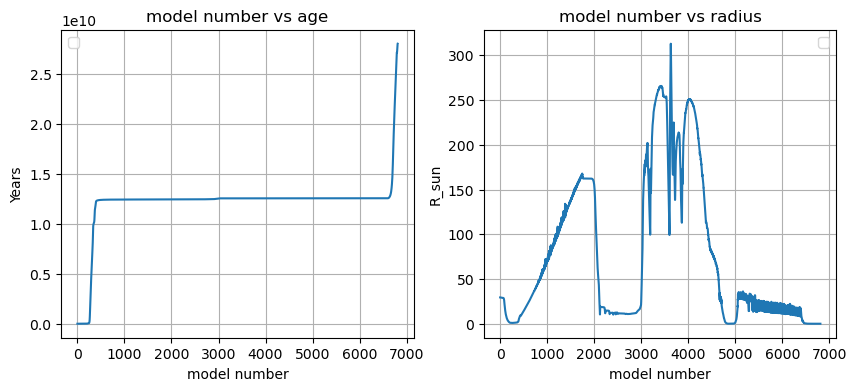

In [7]:
fig_age_rad, (ax_age, ax_rad) = plt.subplots(1, 2, figsize=(10, 4))

ax_age.plot(mod_num,hist_age)
ax_age.set_xlabel("model number")
ax_age.set_ylabel("star age")
ax_age.set_ylabel("Years")
#ax_age.set_yscale('log')
ax_age.legend()
ax_age.grid()
ax_age.set_title("model number vs age")

ax_rad.plot(mod_num,hist_rad)
ax_rad.set_xlabel("model number")
ax_rad.set_ylabel("radius")
ax_rad.set_ylabel("R_sun")
#ax_rad.set_yscale('log')
ax_rad.legend()
ax_rad.grid()
ax_rad.set_title("model number vs radius")

idenifying the area with a radius less than 2 R_sun and is younger than 9 Gyr

In [8]:
locations = np.array([])
new_age = np.array([])
new_rad = np.array([])

for i in range(len(hist_age)):

    if hist_age[i] <= 10e9 and hist_rad[i] <= 2:
        locations = np.append(locations,i)
        new_age = np.append(new_age, hist_age[i])
        new_rad = np.append(new_rad, hist_rad[i])

    else:
        pass

#print(locations)

The function "find_read_profile(filename, model_number, nearest=False, as_table=False)" will round the model number to its nearest profile if "nearest = True", as a result it will try and take the same profile multiple times. the if/else statements combat this by checking if a random data point is the same as that point in the previous profile. If it is the same it is assumed to be the same profile. Commented out are print statements which will show thinsg such as if is the same or different profile on a loop; the total numeber of times it tried the same and differnt profiles.

done


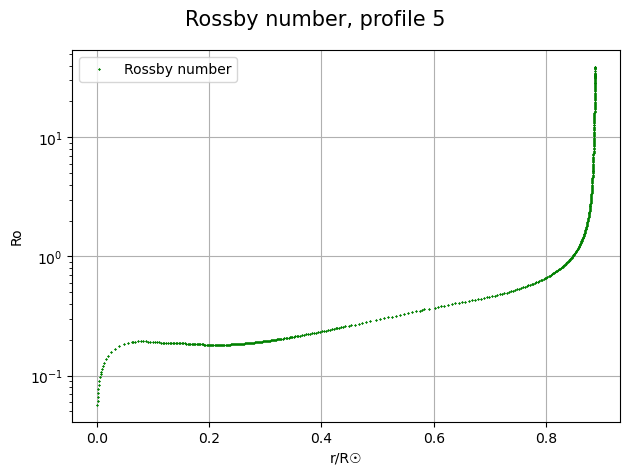

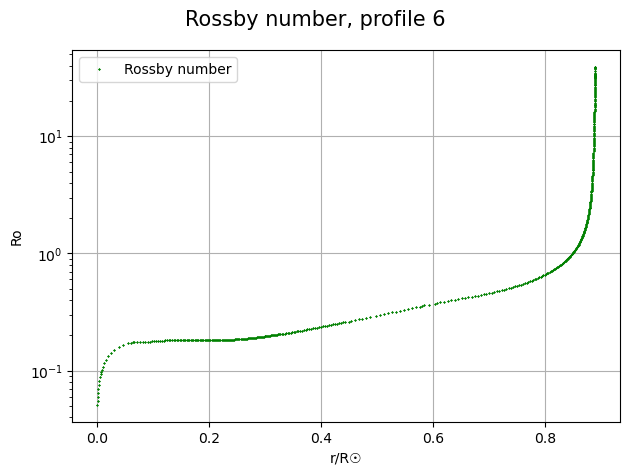

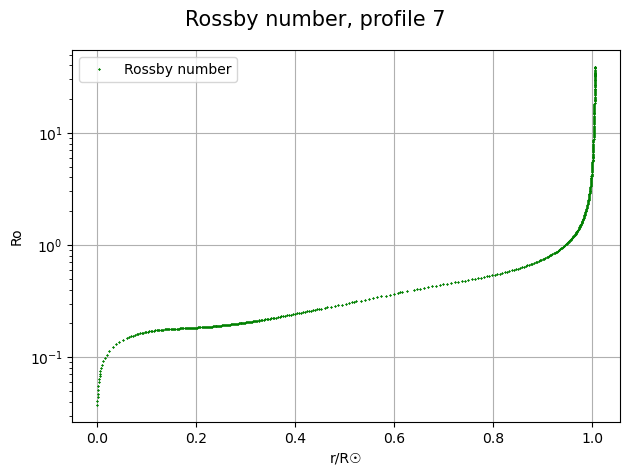

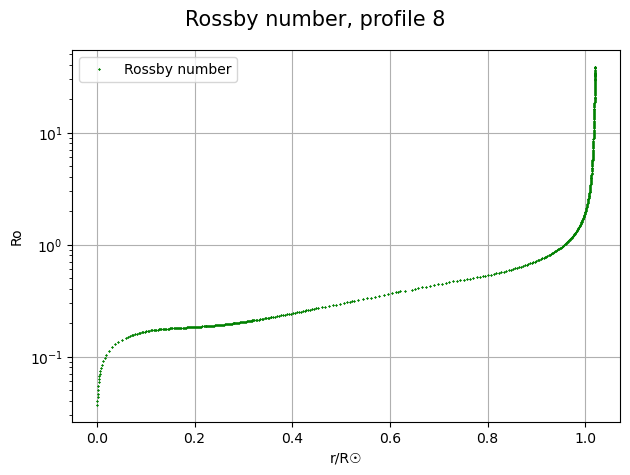

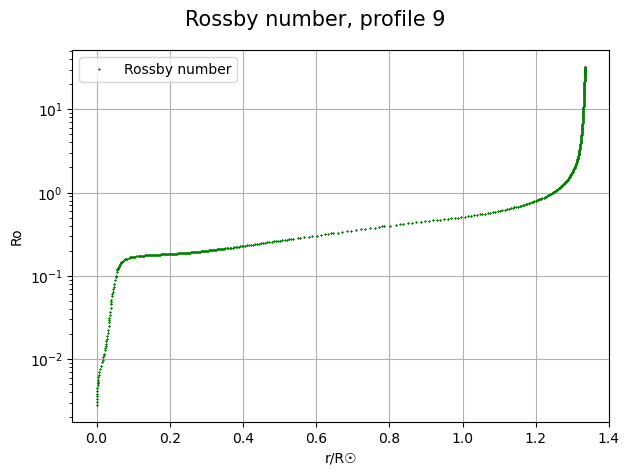

In [9]:
Omega = 450e-9     #angular velocity, hz
previous_check = 0
no_of_same = 0
no_of_different = 0
for i in range (len(locations)):
    data = find_read_profile(profiles_file, locations[i], nearest=True, as_table=False)
    rad = data["radius"]     # radius, R_sun
    rad_metric = rad * 695700000     #radius, m
    lum = data["luminosity"]     # luminosity, L_sun
    lum_metric = lum * 3.828e26     #luminosity, W
    log_dens = data["logRho"]     #10^density, Log(g/cm^3)
    dens = 10 ** log_dens     # density, g/cm^3
    dens_metric = dens * 1000     # desnity, kg/m^3
    mix_length = 0.3 * np.max(rad_metric)
   
    #print(f"run {i} location {locations[i]}")
    #print(f"length of rad {len(rad)}")
    place = random.randint(1, len(rad)-1)     #chosing a random data point to check. to see if the same data set is being used again.
    #print(f"place {place}")
    if i==0:     #if first run doesnt check  if its the same data profile again as it hasnt ran one yet
        pass

    else:
        if previous_check[place] == rad[place]:     #checks to see if its running the same data set again as i think the model number rounds to a profile closest to it.
            #print("same")
            no_of_same += 1
        
        else:
            #print("different")
            no_of_different += 1

            mod_num, prof_num = np.loadtxt(profiles_file, skiprows=1, unpack=True, usecols=(0,2), dtype=int)
            profile_in_question = np.argmin(np.abs(mod_num- locations[i]))     #number of profile in question
    
            temp_rossby = Rossby(L_u = lum_metric, r = rad_metric, rho = dens_metric, omega = Omega, L_m = mix_length)
            Plotting_Rossby_against_Radius(R_o = temp_rossby, r = rad, profile_number = profile_in_question, data = "Rossby number", pdf_loc = pdf_location, png_loc = png_location)

    previous_check = rad     #make teh current data for a profiles radius its comparison.

#print(f" number of the same {no_of_same}, number of different {no_of_different}")
print("done")